# Modelling

In [3]:
# import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from logitplots import plt_confusion_matrix, plt_decision_boundaries, plt_correlation_matrix
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, TimeSeriesSplit, validation_curve
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# import data
data = pd.read_csv("/Users/jiehni/monash/ADS2001_GROUPMC3/data/processed/melb.csv")
data.head()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),...,WindDir_NNW,WindDir_NW,WindDir_S,WindDir_SE,WindDir_SSE,WindDir_SSW,WindDir_SW,WindDir_W,WindDir_WNW,WindDir_WSW
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,11,...,False,False,False,True,False,False,False,False,False,False
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,11,...,False,False,False,True,False,False,False,False,False,False
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,11,...,False,False,False,True,False,False,False,False,False,False
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,11,...,False,False,False,True,False,False,False,False,False,False
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,9,...,False,False,False,False,False,False,False,False,False,False


### Decision Tree for Level of Rain

Decision Tree Level of Rain (no rain: 0mm, light rain: 0-2mm, moderate rain: 2-10mm, heavy rain: 10-50mm, extreme rain: 50+mm) – Jiehni

In [31]:
# create bins for rain level
data["Rainfall Band"] = pd.cut(
    data["Rainfall since 9 am (mm)"],
    bins=[-0.1, 0, 2, 10, 50, np.inf],
    labels=["No Rain", "Light", "Moderate", "Heavy", "Extreme"]
)

# select variables
X = data.drop(["Rainfall since 9 am (mm)", "Rainfall Band", "Rain", "Datetime"], axis=1)
y = data["Rainfall Band"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

In [32]:
print(data["Rainfall Band"].value_counts())

Rainfall Band
No Rain     245274
Light        51625
Moderate     25153
Heavy         7591
Extreme          4
Name: count, dtype: int64


In [33]:
# hyperparameter tuning with time series cv and random search
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [10, 20, 50, 100],
    'min_samples_leaf': [5, 10, 20, 50]
}

rand = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,  
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand.fit(X_train, y_train)

print("Best params:", rand.best_params_)
print("Best time-series CV score:", rand.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'min_samples_split': 20, 'min_samples_leaf': 5, 'max_depth': 20}
Best time-series CV score: 0.8350160780643513


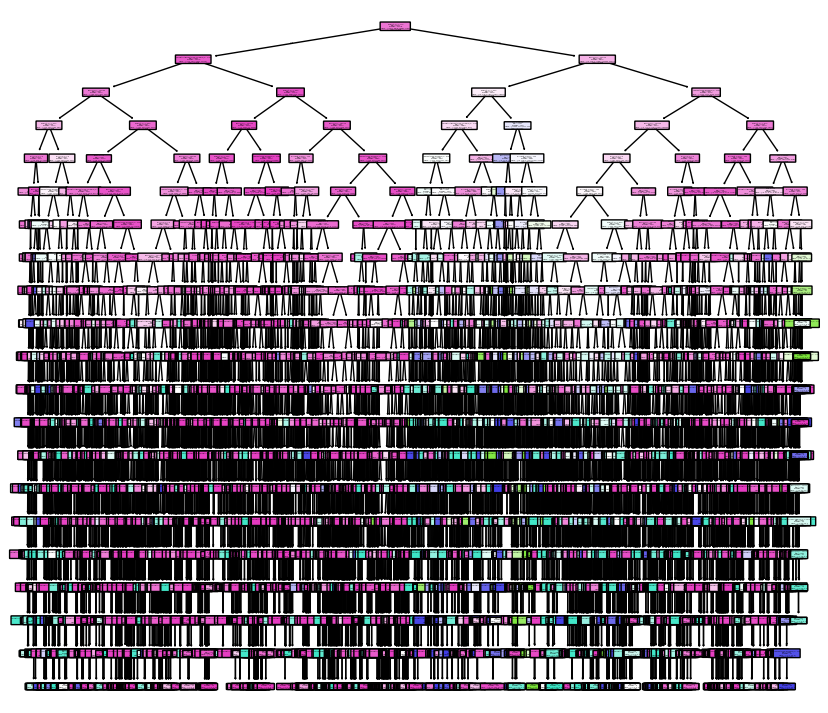

In [34]:
data_dtc = DecisionTreeClassifier(
    random_state = 42, 
    min_samples_split=20,
    min_samples_leaf=5,
    max_depth=20) 

data_dtc = data_dtc.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 9))
plot_tree(
    data_dtc,
    filled=True,
    rounded=True,
    class_names=data_dtc.classes_,
    feature_names=X.columns,
    ax=ax
)
plt.show()

In [35]:
# feature importance
importance = pd.Series(data_dtc.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

Humidity (%)                            0.154220
Day                                     0.153992
MSLP (hPa)                              0.149453
Year                                    0.094291
Month                                   0.090650
Hour                                    0.076921
Apparent Temp (degrees C)               0.050559
Calculated Apparent Temp (degrees C)    0.047828
Air Temp (degrees C)                    0.038526
Wind Gust  (km/h)                       0.028012
E (hPa)                                 0.020620
gamma                                   0.018707
WindDir_N                               0.018117
Dew Pt Temp (degrees C)                 0.013109
Wind Speed (km/h)                       0.008503
Calculated Dew Pt Temp (degrees C)      0.008312
WindDir_S                               0.003659
WindDir_NNE                             0.003519
WindDir_SW                              0.003307
WindDir_W                               0.002949
WindDir_WSW         

Most important features are Day, MSLP (hPa) and Humidity (%).

Decision Tree Accuracy: 0.89


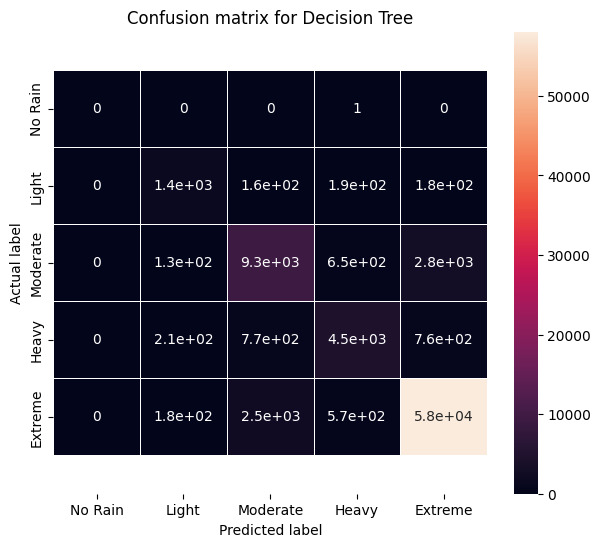

In [36]:
Y_pred = data_dtc.predict(X_test)
cm = confusion_matrix(y_test, Y_pred)
plt_confusion_matrix(cm, ["No Rain", "Light", "Moderate", "Heavy", "Extreme"], "Decision Tree") 
print("Decision Tree Accuracy:",np.round(accuracy_score(y_test, Y_pred),3))

In [37]:
data_dtc.fit(X_train, y_train)

train_score = data_dtc.score(X_train, y_train)
test_score = data_dtc.score(X_test, y_test)

print(f"Train score: {train_score}\nTest score: {test_score}")

Train score: 0.9312718668473314
Test score: 0.889530650876086


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


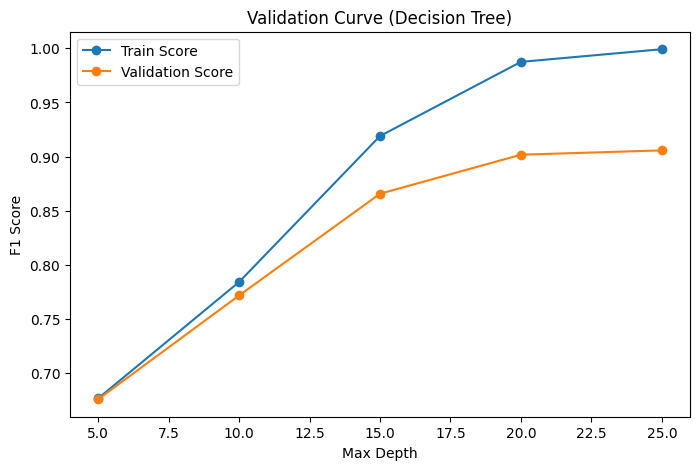

In [48]:
param_range = [5, 10, 15, 20, 25]

train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="f1_weighted"
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))

plt.plot(param_range, train_mean, marker='o', label="Train Score")
plt.plot(param_range, val_mean, marker='o', label="Validation Score")

plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("Validation Curve (Decision Tree)")
plt.legend()

plt.show()

In [49]:
labels = ["No Rain", "Light", "Moderate", "Heavy", "Extreme"]

print(classification_report(y_test, Y_pred, labels=labels))

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

     No Rain       0.94      0.95      0.94     61277
       Light       0.73      0.72      0.73     12957
    Moderate       0.76      0.72      0.74      6257
       Heavy       0.73      0.72      0.72      1920
     Extreme       0.00      0.00      0.00         1

    accuracy                           0.89     82412
   macro avg       0.63      0.62      0.63     82412
weighted avg       0.89      0.89      0.89     82412



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The dataset has severe class imbalance with majority of observations belonging to the "No Rain" class and only 4 "Extreme" rainfall events. As a result, the decision tree model is highly biased to the majority classes as shown by the low recall and f1 scores.

Hence, accuracy alone is not a reliable metric and the class imbalance must be addressed to improve the model's performance. To combat this we will reduce the number of classes and remove "Extreme" class. 

In [5]:
# reduce number of classes
data["Rainfall Band"] = pd.cut(
    data["Rainfall since 9 am (mm)"],
    bins=[-0.1, 0, 5, 20, np.inf],
    labels=["No Rain", "Light", "Moderate", "Heavy"]
)

# select variables
X = data.drop(["Rainfall since 9 am (mm)", "Rainfall Band", "Rain", "Datetime"], axis=1)
y = data["Rainfall Band"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

In [6]:
print(data["Rainfall Band"].value_counts())

Rainfall Band
No Rain     245274
Light        67670
Moderate     14273
Heavy         2430
Name: count, dtype: int64


This distribution is more even compared to before

In [52]:
rand = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,  
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand.fit(X_train, y_train)

print("Best params:", rand.best_params_)
print("Best time-series CV score:", rand.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'min_samples_split': 20, 'min_samples_leaf': 5, 'max_depth': 20}
Best time-series CV score: 0.8507115863402106


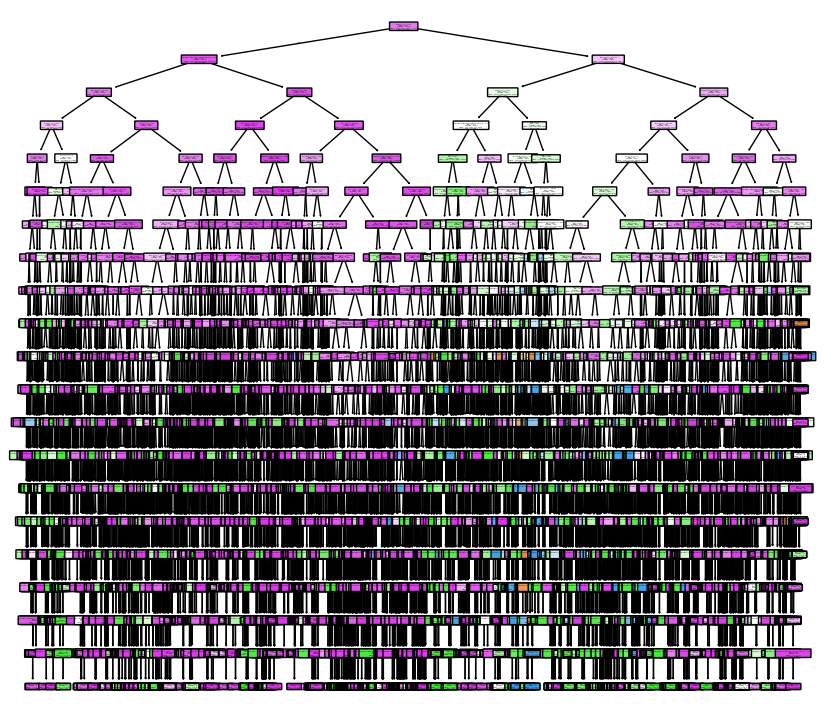

In [62]:
data_dtc2 = DecisionTreeClassifier(
    random_state = 42, 
    min_samples_split=20,
    min_samples_leaf=5,
    max_depth=20) 

data_dtc2 = data_dtc2.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 9))
plot_tree(
    data_dtc2,
    filled=True,
    rounded=True,
    class_names=data_dtc2.classes_,
    feature_names=X.columns,
    ax=ax
)
plt.show()

Decision Tree Accuracy: 0.853


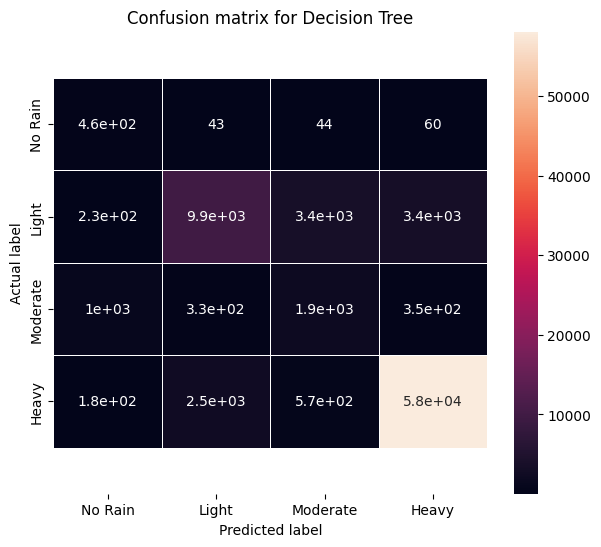

In [64]:
Y_pred = data_dtc.predict(X_test)
cm = confusion_matrix(y_test, Y_pred)
plt_confusion_matrix(cm, ["No Rain", "Light", "Moderate", "Heavy"], "Decision Tree") 
print("Decision Tree Accuracy:",np.round(accuracy_score(y_test, Y_pred),3))

In [65]:
data_dtc2.fit(X_train, y_train)

train_score = data_dtc2.score(X_train, y_train)
test_score = data_dtc2.score(X_test, y_test)

print(f"Train score: {train_score}\nTest score: {test_score}")

Train score: 0.9396566020183227
Test score: 0.8993107799834975


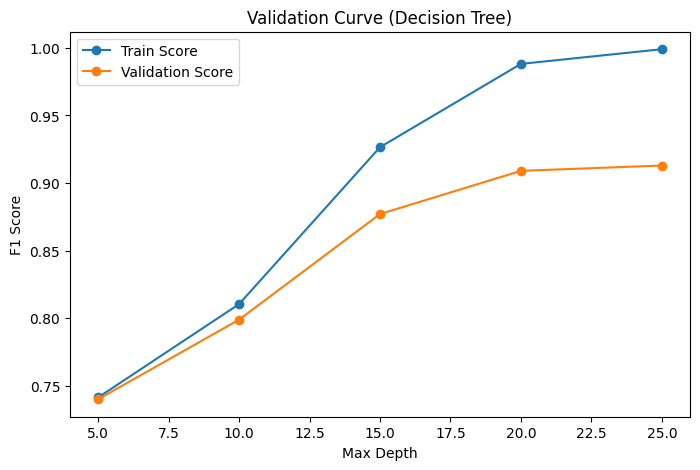

In [66]:
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="f1_weighted"
)

train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure(figsize=(8,5))

plt.plot(param_range, train_mean, marker='o', label="Train Score")
plt.plot(param_range, val_mean, marker='o', label="Validation Score")

plt.xlabel("Max Depth")
plt.ylabel("F1 Score")
plt.title("Validation Curve (Decision Tree)")
plt.legend()

plt.show()

In [67]:
labels = ["No Rain", "Light", "Moderate", "Heavy"]

print(classification_report(y_test, Y_pred, labels=labels))

              precision    recall  f1-score   support

     No Rain       0.94      0.95      0.94     61277
       Light       0.78      0.58      0.67     16944
    Moderate       0.31      0.52      0.39      3582
       Heavy       0.24      0.76      0.37       609

    accuracy                           0.85     82412
   macro avg       0.57      0.70      0.59     82412
weighted avg       0.87      0.85      0.86     82412



The model’s accuracy decreased to 0.861 as it attempted to better predict minority classes. 

In [68]:
rand = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,  
    cv=tscv,
    scoring='f1_weighted',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand.fit(X_train, y_train)

print("Best params:", rand.best_params_)
print("Best time-series CV score:", rand.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'min_samples_split': 20, 'min_samples_leaf': 5, 'max_depth': 20}
Best time-series CV score: 0.8507115863402106


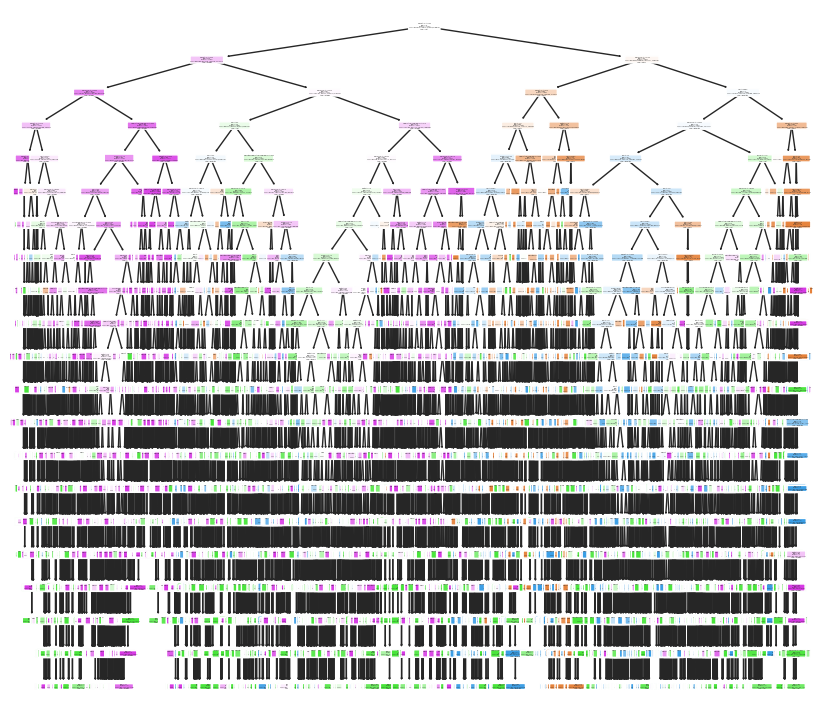

In [27]:
# balance classes
data_dtc_balanced = DecisionTreeClassifier(
    random_state = 42, 
    min_samples_split=20,
    min_samples_leaf=5,
    max_depth=20,
    class_weight="balanced") 

data_dtc_balanced = data_dtc_balanced.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(10, 9))
plot_tree(
    data_dtc_balanced,
    filled=True,
    rounded=True,
    class_names=data_dtc_balanced.classes_,
    feature_names=X.columns,
    ax=ax
)
plt.show()

Decision Tree Accuracy: 0.873


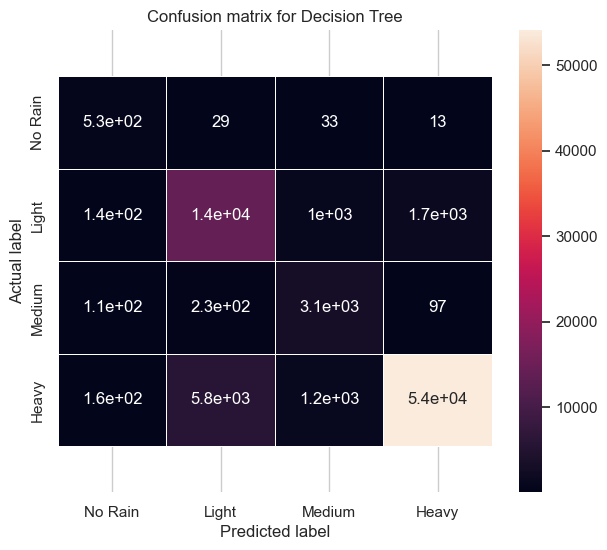

In [28]:
Y_pred_balanced = data_dtc_balanced.predict(X_test)
cm = confusion_matrix(y_test, Y_pred_balanced)
plt_confusion_matrix(cm, ["No Rain", "Light", "Medium", "Heavy"], "Decision Tree") 
print("Decision Tree Accuracy:",np.round(accuracy_score(y_test, Y_pred_balanced),3))

In [29]:
tfp = 0
tfn = 0

for i, label in enumerate(labels):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - (tp + fp + fn)

    tfp = tfp + fp
    tfn = tfn + fn

    print(f"\n{label}")
    print(f"True Positives: {tp}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Negatives: {tn}")

print(f"\nTotal False Positives: {tfp}")
print(f"Total False Negatives: {tfn}")


No Rain
True Positives: 534
False Positives: 411
False Negatives: 75
True Negatives: 81392

Light
True Positives: 14139
False Positives: 6058
False Negatives: 2805
True Negatives: 59410

Moderate
True Positives: 3138
False Positives: 2245
False Negatives: 444
True Negatives: 76585

Heavy
True Positives: 54125
False Positives: 1762
False Negatives: 7152
True Negatives: 19373

Total False Positives: 10476
Total False Negatives: 10476


In [72]:
data_dtc_balanced.fit(X_train, y_train)

train_score = data_dtc_balanced.score(X_train, y_train)
test_score = data_dtc_balanced.score(X_test, y_test)

print(f"Train score: {train_score}\nTest score: {test_score}")

Train score: 0.9095071490686998
Test score: 0.8728825899140902


In [74]:
labels = ["No Rain", "Light", "Moderate", "Heavy"]

print(classification_report(y_test, Y_pred_balanced, labels=labels))

              precision    recall  f1-score   support

     No Rain       0.97      0.88      0.92     61277
       Light       0.70      0.83      0.76     16944
    Moderate       0.58      0.88      0.70      3582
       Heavy       0.57      0.88      0.69       609

    accuracy                           0.87     82412
   macro avg       0.70      0.87      0.77     82412
weighted avg       0.89      0.87      0.88     82412



Applying class weighting improved the model’s ability to detect minority classes such as heavy rainfall but overall performance remained limited due to the severe class imbalance. 

The model’s accuracy increased after class balancing. Performance improved drastically for "Heavy" and "Medium". Class weighting helped to reduce bias but it cannot fully compensate for insufficient data in rare categories.

In [78]:
y_shuffled = np.random.permutation(y)

scores = cross_val_score(
    DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    X,
    y_shuffled,
    cv=5,
    scoring="f1_weighted"
)

print(scores.mean())

0.43742959328137865


This checks whether the model is learning real patterns or just picking up unintended information from the data. By shuffling the labels, any true relationship between the features and the target is removed.

### Gradient Boosting

In [95]:
param_dist = {
    "max_iter": [100, 150, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0]
}

rand = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=tscv,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rand.fit(X_train, y_train)

print("Best params:", rand.best_params_)
print("Best time-series CV score:", rand.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 150, 'learning_rate': 0.05, 'l2_regularization': 0.1}
Best time-series CV score: 0.7404921234993499


In [8]:
gb_model = HistGradientBoostingClassifier(
    random_state=42, 
    min_samples_leaf=20,
    max_leaf_nodes=63,
    max_iter=300,
    learning_rate=0.05,
    l2_regularization=0.1,
    class_weight="balanced") 

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", np.round(accuracy_score(y_test, y_pred_gb), 3))

labels = ["No Rain", "Light", "Moderate", "Heavy"]
print(classification_report(y_test, y_pred_gb, labels=labels))

Gradient Boosting Accuracy: 0.917
              precision    recall  f1-score   support

     No Rain       0.98      0.92      0.95     61277
       Light       0.76      0.91      0.83     16944
    Moderate       0.80      0.97      0.88      3582
       Heavy       0.96      0.97      0.96       609

    accuracy                           0.92     82412
   macro avg       0.87      0.94      0.90     82412
weighted avg       0.93      0.92      0.92     82412



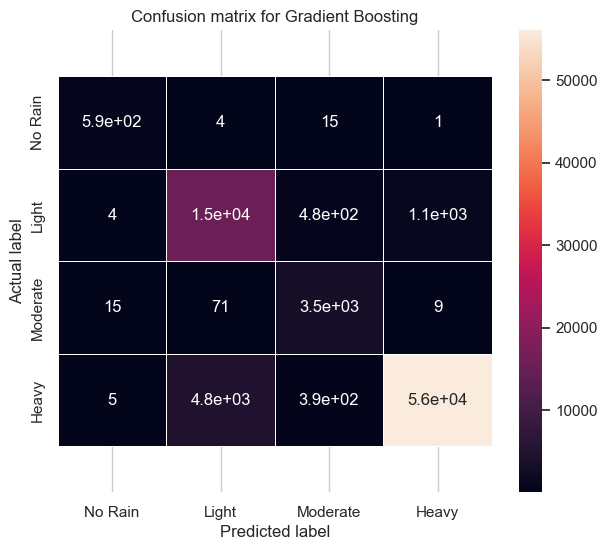

In [10]:
cm = confusion_matrix(y_test, y_pred_gb)
plt_confusion_matrix(cm, ["No Rain", "Light", "Moderate", "Heavy"], "Gradient Boosting") 

In [25]:
tfp = 0
tfn = 0

for i, label in enumerate(labels):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - (tp + fp + fn)

    tfp = tfp + fp
    tfn = tfn + fn

    print(f"\n{label}")
    print(f"True Positives: {tp}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Negatives: {tn}")

print(f"\nTotal False Positives: {tfp}")
print(f"Total False Negatives: {tfn}")


No Rain
True Positives: 589
False Positives: 24
False Negatives: 20
True Negatives: 81779

Light
True Positives: 15374
False Positives: 4877
False Negatives: 1570
True Negatives: 60591

Moderate
True Positives: 3487
False Positives: 876
False Negatives: 95
True Negatives: 77954

Heavy
True Positives: 56084
False Positives: 1101
False Negatives: 5193
True Negatives: 20034

Total False Positives: 6878
Total False Negatives: 6878


In [11]:
gb_model.fit(X_train, y_train)

train_score = gb_model.score(X_train, y_train)
test_score = gb_model.score(X_test, y_test)

print(f"Train score: {train_score}\nTest score: {test_score}")

Train score: 0.9289137864784517
Test score: 0.9165412803960589


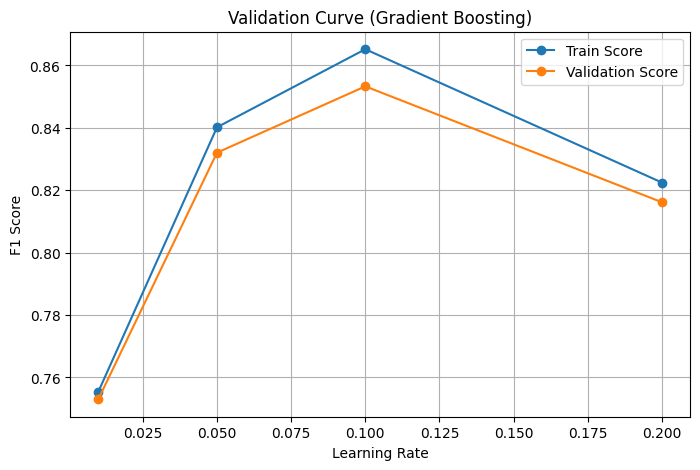

In [105]:
param_range = [0.01, 0.05, 0.1, 0.2]

train_scores, val_scores = validation_curve(
    HistGradientBoostingClassifier(random_state=42),
    X_train,
    y_train,
    param_name="learning_rate",
    param_range=param_range,
    cv=5,
    scoring="f1_weighted"
)

# average scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# plot
plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, marker='o', label="Train Score")
plt.plot(param_range, val_mean, marker='o', label="Validation Score")

plt.xlabel("Learning Rate")
plt.ylabel("F1 Score")
plt.title("Validation Curve (Gradient Boosting)")
plt.legend()
plt.grid(True)

plt.show()

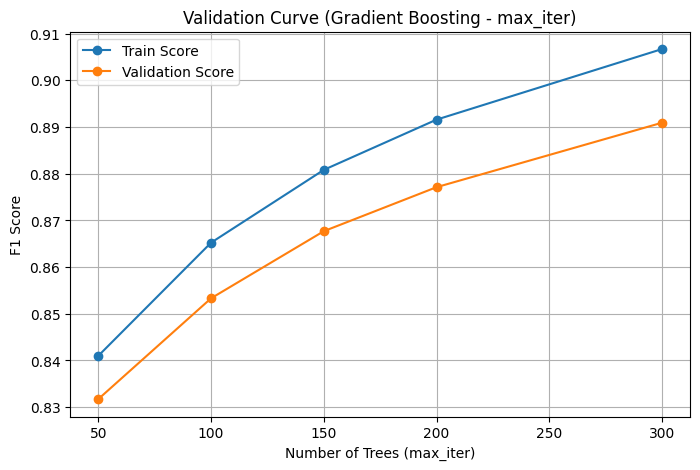

In [106]:
param_range = [50, 100, 150, 200, 300]

train_scores, val_scores = validation_curve(
    HistGradientBoostingClassifier(
        random_state=42,
        learning_rate=0.1  # keep fixed while testing max_iter
    ),
    X_train,
    y_train,
    param_name="max_iter",
    param_range=param_range,
    cv=5,
    scoring="f1_weighted"
)

# mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# plot
plt.figure(figsize=(8,5))
plt.plot(param_range, train_mean, marker='o', label="Train Score")
plt.plot(param_range, val_mean, marker='o', label="Validation Score")

plt.xlabel("Number of Trees (max_iter)")
plt.ylabel("F1 Score")
plt.title("Validation Curve (Gradient Boosting - max_iter)")
plt.legend()
plt.grid(True)

plt.show()

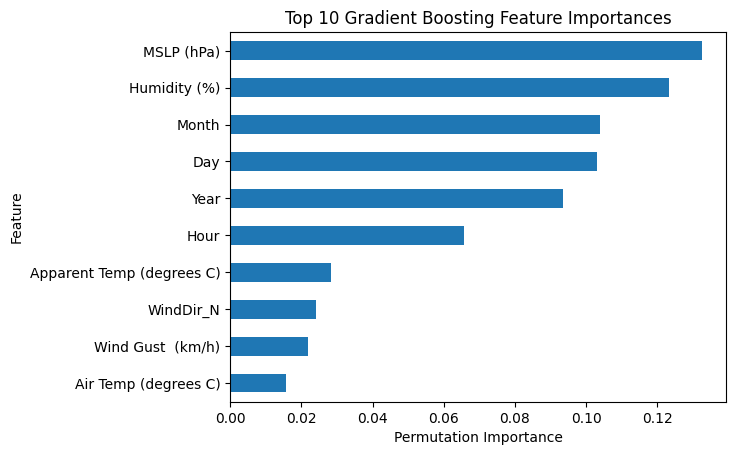

In [110]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    gb_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_weighted"
)

importances = pd.Series(
    result.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

importances.head(10).plot(kind="barh")

plt.title("Top 10 Gradient Boosting Feature Importances")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

### Gradient Boosting Prediction

In [12]:
march_2021 = data[(data["Year"] == 2021) & (data["Month"] == 3)].copy()

future_data = march_2021.copy()
future_data["Year"] = 2022

future_data = future_data.reindex(columns=X_train.columns, fill_value=0)
future_data = future_data.drop(columns=["Rainfall since 9am (mm)"], errors="ignore")

In [13]:
# predict
future_X = future_data.reindex(columns=X_train.columns, fill_value=0)

preds = gb_model.predict(future_X)

future_results = future_data.copy()
future_results["Predicted_Rainfall_Level"] = preds

# convert rainfall labels
rain_order = {
    "No Rain": 0,
    "Light": 1,
    "Medium": 2,
    "Moderate": 2,
    "Heavy": 3
}

future_results["Rainfall_Index"] = future_results["Predicted_Rainfall_Level"].map(rain_order)

# daily max rainfall level
daily_preds_max = (
    future_results
    .groupby(["Year", "Month", "Day"])["Rainfall_Index"]
    .max()
    .reset_index()
)

# convert numbers
reverse_map = {
    0: "No Rain",
    1: "Light",
    2: "Moderate",
    3: "Heavy"
}

daily_preds_max["Predicted_Rainfall_Level"] = daily_preds_max["Rainfall_Index"].map(reverse_map)

daily_preds_max.head()

,Year,Month,Day,Rainfall_Index,Predicted_Rainfall_Level
0,2022,3,1.0,1,Light
1,2022,3,2.0,1,Light
2,2022,3,3.0,1,Light
3,2022,3,4.0,1,Light
4,2022,3,5.0,1,Light


In [14]:
print(daily_preds_max)

    Year  Month   Day  Rainfall_Index Predicted_Rainfall_Level
0   2022      3   1.0               1                    Light
1   2022      3   2.0               1                    Light
2   2022      3   3.0               1                    Light
3   2022      3   4.0               1                    Light
4   2022      3   5.0               1                    Light
5   2022      3   6.0               1                    Light
6   2022      3   7.0               1                    Light
7   2022      3   8.0               3                    Heavy
8   2022      3   9.0               1                    Light
9   2022      3  10.0               1                    Light
10  2022      3  11.0               1                    Light
11  2022      3  12.0               1                    Light
12  2022      3  13.0               2                 Moderate
13  2022      3  14.0               2                 Moderate
14  2022      3  15.0               1                  

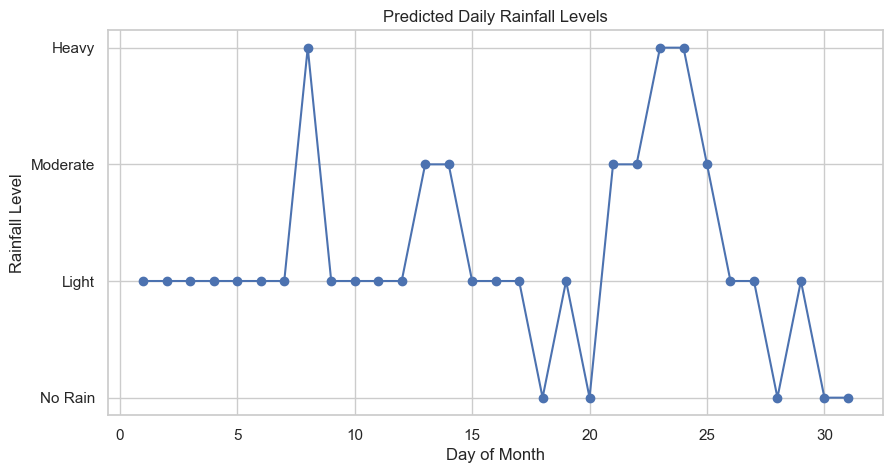

In [15]:
plt.figure(figsize=(10,5))
plt.plot(daily_preds_max["Day"], daily_preds_max["Rainfall_Index"], marker="o")

plt.yticks([0,1,2,3], ["No Rain", "Light", "Moderate", "Heavy"])
plt.xlabel("Day of Month")
plt.ylabel("Rainfall Level")
plt.title("Predicted Daily Rainfall Levels")
plt.grid(True)
plt.show()

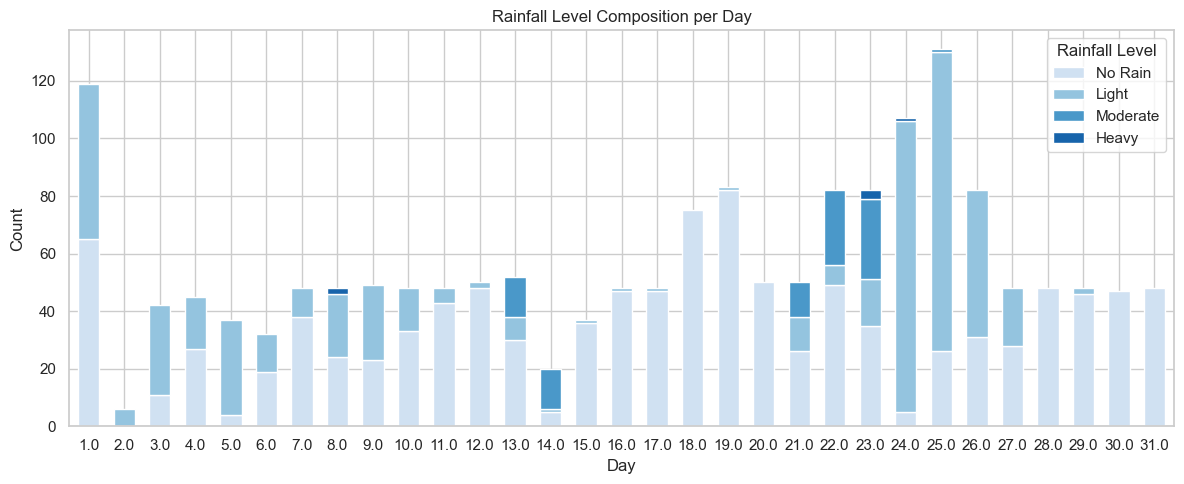

In [16]:
sns.set_theme(style="whitegrid")

order = ["No Rain", "Light", "Moderate", "Heavy"]

table = pd.crosstab(
    future_results["Day"],
    future_results["Predicted_Rainfall_Level"]
).reindex(columns=order, fill_value=0)

colors = sns.color_palette("Blues", n_colors=len(order))

table.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(12,5),
    width=0.6
)

plt.title("Rainfall Level Composition per Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Rainfall Level")
plt.tight_layout()
plt.show()

/var/folders/0d/qf_dfhwn3vjd4fvry35670240000gn/T/ipykernel_21276/2964670843.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pivot_mapped = pivot.replace(mapping)


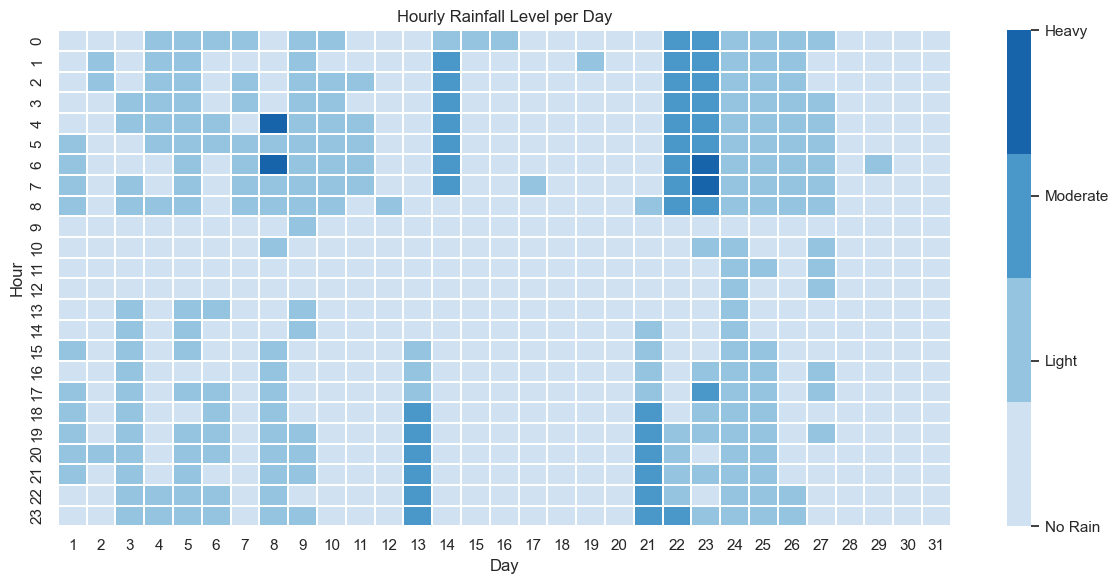

In [20]:
sns.set_theme(style="whitegrid")

order = ["No Rain", "Light", "Moderate", "Heavy"]

# create pivot with most frequent rainfall level per (day, hour)
pivot = future_results.pivot_table(
    index="Hour",
    columns="Day",
    values="Predicted_Rainfall_Level",
    aggfunc=lambda x: x.mode().iloc[0] if not x.mode().empty else "No Rain"
)

# reindex to full 24 hours and 31 days
pivot = pivot.reindex(index=range(24), columns=range(1, 32))

# fill missing cells so they don't appear white
pivot = pivot.fillna("No Rain")

# map categories to numbers
mapping = {k: i for i, k in enumerate(order)}
pivot_mapped = pivot.replace(mapping)

# colours
cmap = sns.color_palette("Blues", n_colors=len(order))

plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    pivot_mapped,
    cmap=cmap,
    cbar=True,
    linewidths=0.1
)

# fix colorbar labels
colorbar = ax.collections[0].colorbar
colorbar.set_ticks(range(len(order)))
colorbar.set_ticklabels(order)

plt.title("Hourly Rainfall Level per Day")
plt.xlabel("Day")
plt.ylabel("Hour")
plt.tight_layout()
plt.show()

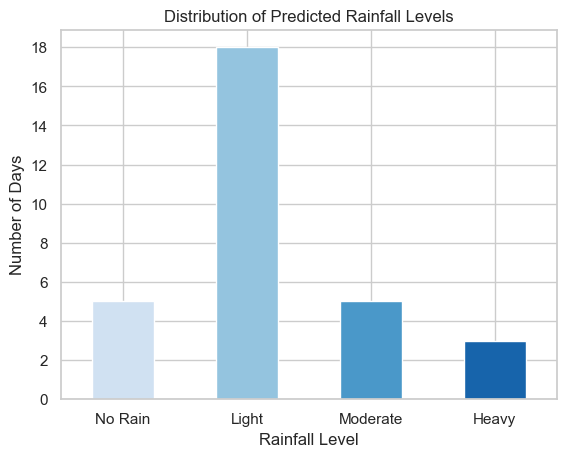

In [18]:
sns.set_theme(style="whitegrid")

order = ['No Rain', 'Light', 'Moderate', 'Heavy']

counts = daily_preds_max["Predicted_Rainfall_Level"].value_counts().reindex(order)

colors = sns.color_palette("Blues", n_colors=len(order))

counts.plot(kind="bar", color=colors)

plt.title("Distribution of Predicted Rainfall Levels")
plt.xlabel("Rainfall Level")
plt.ylabel("Number of Days")
plt.xticks(rotation=0)
plt.yticks(np.arange(0, counts.max()+2, 2))

plt.show()

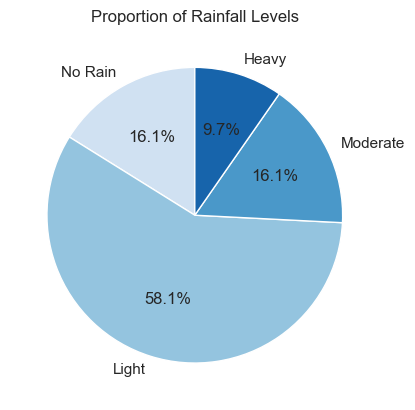

In [19]:
# correct logical order
order = ["No Rain", "Light", "Moderate", "Heavy"]

# reorder counts to match this
counts = daily_preds_max["Predicted_Rainfall_Level"].value_counts().reindex(order)

# create blue gradient (light → dark)
colours = sns.color_palette("Blues", n_colors=len(order))

# plot
counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors=colours,
    startangle=90
)

plt.title("Proportion of Rainfall Levels")
plt.ylabel("")
plt.show()